## Figure 1 - Training plots

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import json, math, re
from pathlib import Path

import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.models.resnet import ResNet, BasicBlock

# RUNS = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_17_run")                       # <-- output dir of train_depth_sweep.py
RUNS = Path('/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/resnet/hackin/aug_17_run')

# DATA = Path("/home/stephen/imagenet")     
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_DEPTHS = {"plain8": 8, "plain14": 14, "plain20": 20, "plain26": 26,
                "plain34": 34, "plain56": 56, "plain74": 74, "resnet74": 74}
MODELS = [m for m in MODEL_DEPTHS if (RUNS / m).exists()]

def color_of(name):
    """Plain nets: dark->light with depth. ResNet: red."""
    if name == "resnet74":
        return "crimson"
    depths = sorted(d for m, d in MODEL_DEPTHS.items() if m != "resnet74")
    return plt.cm.viridis((depths.index(MODEL_DEPTHS[name])+1.0) / (len(depths) +1.0))

print(torch.__version__, device, "| runs found:", MODELS)

2.13.0 cpu | runs found: ['plain8', 'plain14', 'plain20', 'plain26', 'plain34', 'plain56', 'plain74', 'resnet74']


In [3]:
# --- model definitions (mirrors train_depth_sweep.py) ---
class PlainBasicBlock(BasicBlock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.downsample = None

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out

LAYER_CFG = {8: [1,1,1,1], 14: [2,1,1,2], 20: [2,2,3,2], 26: [3,3,3,3],
             34: [4,4,4,4], 56: [3,4,17,3], 74: [3,4,26,3]}

def make_net(depth_target, use_skip, num_classes=1000):
    block = BasicBlock if use_skip else PlainBasicBlock
    model = ResNet(block, LAYER_CFG[depth_target], num_classes=num_classes)
    if depth_target == 8:
        model.layer4 = nn.Identity()
        model.fc = nn.Linear(256, num_classes)
    return model

def blocks_of(model):
    return [b for s in (model.layer1, model.layer2, model.layer3, model.layer4)
            if isinstance(s, nn.Sequential) for b in s]

In [4]:
# --- metrics loading: prefer metrics.npz, fall back to metrics.jsonl ---
def load_metrics(name):
    d = RUNS / name
    if (d / "metrics.npz").exists():
        return dict(np.load(d / "metrics.npz"))
    recs = [json.loads(l) for l in open(d / "metrics.jsonl") if l.strip()]
    out = {}
    for k in recs[0]:
        if k in ("block_grad_norms", "block_acts"):
            continue
        out[k] = np.array([r.get(k, np.nan) for r in recs], dtype=np.float64)
    out["block_grad_norms"] = np.array([r["block_grad_norms"] for r in recs])
    return out

M = {name: load_metrics(name) for name in MODELS}
for name in MODELS:
    print(f"{name:9s} records={len(M[name]['step']):5d} "
          f"last step={int(M[name]['step'][-1])}")

plain8    records=  400 last step=40000
plain14   records=  500 last step=50000
plain20   records=  600 last step=60000
plain26   records=  700 last step=70000
plain34   records=  800 last step=80000
plain56   records=  900 last step=90000
plain74   records= 1000 last step=100000
resnet74  records= 1100 last step=110000


In [5]:
def list_ckpts(name):
    return sorted(int(re.search(r"(\d+)", p.stem).group(1))
                  for p in (RUNS / name).glob("ckpt_step*.pt"))

def load_model(name, step=None):
    d = RUNS / name
    path = d / "final.pt" if step is None else d / f"ckpt_step{step:06d}.pt"
    model = make_net(MODEL_DEPTHS[name], use_skip=name.startswith("resnet"))
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

print("plain74 checkpoints:", list_ckpts("plain74")[:5], "...",
      list_ckpts("plain74")[-2:])

plain74 checkpoints: [1000, 2000, 3000, 4000, 5000] ... [99000, 100000]


In [6]:
def style_ax(ax, color=CHILL_BROWN, tick_fontsize=15):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both', labelsize=tick_fontsize)
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

<Figure size 640x480 with 0 Axes>

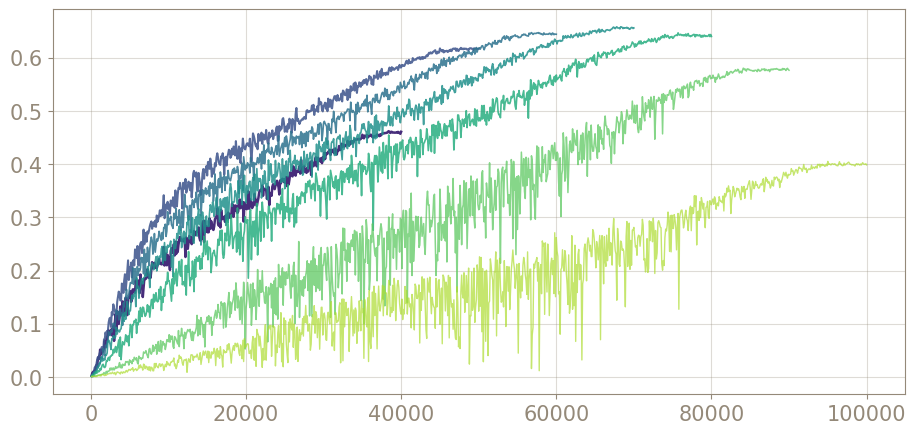

In [11]:
plt.clf()
fig= plt.figure(figsize=(11, 5)) #, facecolor='k')
ax=fig.add_subplot(111) #, facecolor='k')
m='plain8'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.8, alpha=1.0)

m='plain14'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.5, alpha=0.85)

m='plain20'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

m='plain26'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

m='plain34'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

m='plain56'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.1, alpha=0.75)

m='plain74'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1., alpha=0.7)

# m='resnet74'
# plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.5, alpha=0.9)

style_ax(ax)

ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
plt.savefig('/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/ai_book_vol_2/resnets/graphics/accuracy_curves_1.svg')

<Figure size 640x480 with 0 Axes>

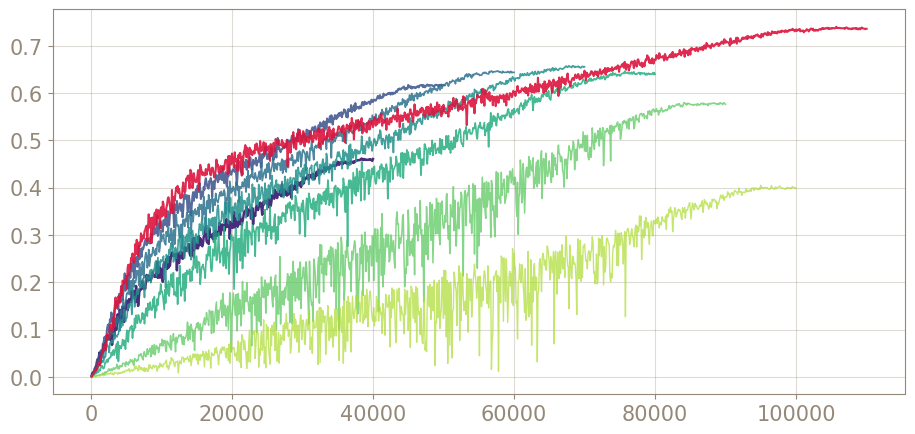

In [10]:
plt.clf()
fig= plt.figure(figsize=(11, 5)) #, facecolor='k')
ax=fig.add_subplot(111) #, facecolor='k')
m='plain8'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.8, alpha=1.0)

m='plain14'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.5, alpha=0.85)

m='plain20'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

m='plain26'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

m='plain34'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

m='plain56'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.1, alpha=0.75)

m='plain74'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1., alpha=0.7)

m='resnet74'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.5, alpha=0.9)

style_ax(ax)

ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
plt.savefig('/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/ai_book_vol_2/resnets/graphics/accuracy_curves_2.svg')